Objective:
- Load RAW SAMSum data from artifacts
- Analyze token lengths using Pegasus tokenizer
- Determine safe max_input_length and max_target_length
- Finalize configuration values

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install -r /content/drive/MyDrive/ml_projects/NLP_Text_Summarization/requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 96.6 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=62d0ed8d270c8fb9c345c0066c472cf2aa0b2585f3cc4f8a39c5a6d331346c8a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [23]:
from pathlib import Path
import json
import numpy as np
from transformers import AutoTokenizer
from matplotlib import pyplot as plt

In [5]:
RAW_DATA_DIR = Path("/content/drive/MyDrive/ml_projects/NLP_Text_Summarization/artifacts/data/raw")

train_path = RAW_DATA_DIR / "samsum_train.json"
val_path = RAW_DATA_DIR / "samsum_validation.json"
test_path = RAW_DATA_DIR / "samsum_test.json"
RAW_DATA_DIR

PosixPath('/content/drive/MyDrive/ml_projects/NLP_Text_Summarization/artifacts/data/raw')

In [7]:
with open(train_path, "r", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline())

{"id":"13818513","dialogue":"Amanda: I baked  cookies. Do you want some?\nJerry: Sure!\nAmanda: I'll bring you tomorrow :-)","summary":"Amanda baked cookies and will bring Jerry some tomorrow."}

{"id":"13728867","dialogue":"Olivia: Who are you voting for in this election? \nOliver: Liberals as always.\nOlivia: Me too!!\nOliver: Great","summary":"Olivia and Olivier are voting for liberals in this election. "}

{"id":"13681000","dialogue":"Tim: Hi, what's up?\nKim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating\nTim: What did you plan on doing?\nKim: Oh you know, uni stuff and unfucking my room\nKim: Maybe tomorrow I'll move my ass and do everything\nKim: We were going to defrost a fridge so instead of shopping I'll eat some defrosted veggies\nTim: For doing stuff I recommend Pomodoro technique where u use breaks for doing chores\nTim: It really helps\nKim: thanks, maybe I'll do that\nTim: I also like using post-its in kaban style","summary":"Kim may try the 

In [9]:
from datasets import load_dataset

data_files = {
    "train": str(train_path),
    "validation": str(val_path),
    "test": str(test_path),
}
dataset = load_dataset("json", data_files=data_files)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [10]:
train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

In [12]:
train_data[0].keys()

dict_keys(['id', 'dialogue', 'summary'])

In [14]:
tokenizer = AutoTokenizer.from_pretrained("google/pegasus-large")

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

In [15]:
def get_token_lengths(texts):
    return [len(tokenizer(text)["input_ids"]) for text in texts]

In [16]:
train_dialogues = dataset["train"]["dialogue"]
train_summaries = dataset["train"]["summary"]

In [17]:
dialogue_token_lengths = get_token_lengths(train_dialogues)
summary_token_lengths = get_token_lengths(train_summaries)

Token indices sequence length is longer than the specified maximum sequence length for this model (1044 > 1024). Running this sequence through the model will result in indexing errors


In [25]:
np.percentile(dialogue_token_lengths, [50, 75, 90, 95, 99, 99.999])

array([ 106.    ,  180.    ,  266.    ,  329.    ,  479.    , 1025.5875])

In [19]:
np.percentile(summary_token_lengths, [50, 75, 90, 95, 99])

array([23., 33., 45., 53., 65.])

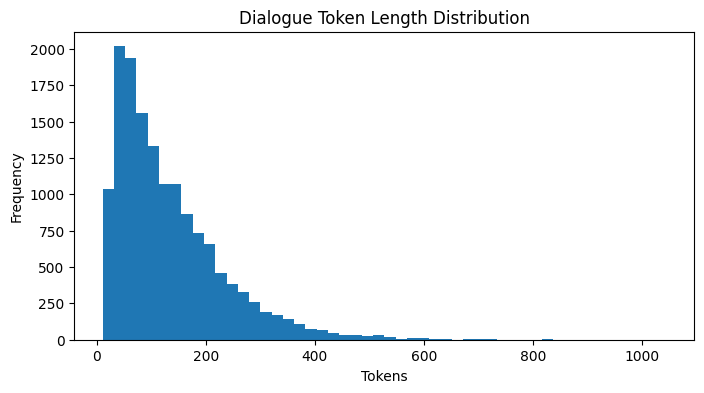

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(dialogue_token_lengths, bins=50)
plt.title("Dialogue Token Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()